<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/Multi_Layer_Perceptron_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [3]:
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(8,)
    ),
    Dense(
        32,
        activation='relu'
    ),
    Dense(
        16,
        activation='relu'
    ),
    Dense(
        1
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics=['mae']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.2317 - mae: 0.6420 - val_loss: 0.4712 - val_mae: 0.4904
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4363 - mae: 0.4498 - val_loss: 0.4144 - val_mae: 0.4449
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3633 - mae: 0.4281 - val_loss: 0.3795 - val_mae: 0.4331
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3432 - mae: 0.4149 - val_loss: 0.3663 - val_mae: 0.4211
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3337 - mae: 0.4076 - val_loss: 0.3844 - val_mae: 0.4373
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3256 - mae: 0.4019 - val_loss: 0.3571 - val_mae: 0.4097
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3155 - mae: 0.3928 - val_loss: 0.3346 - val_mae: 0.3970
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3057 - mae: 0.3856 - val_loss: 0.3411 - val_mae: 0.4031
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

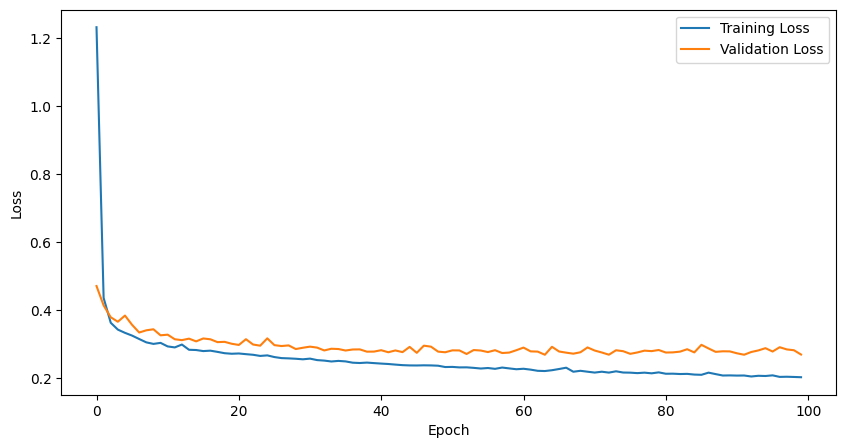

In [13]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [14]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:",loss)
print("Test MAE:",mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2621 - mae: 0.3367
Test Loss: 0.2621294856071472
Test MAE: 0.33674290776252747


In [15]:
predictions = model.predict(X_test)

print(predictions[:5])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0.52776885]
 [1.1185822 ]
 [4.911663  ]
 [2.4951875 ]
 [2.4054015 ]]


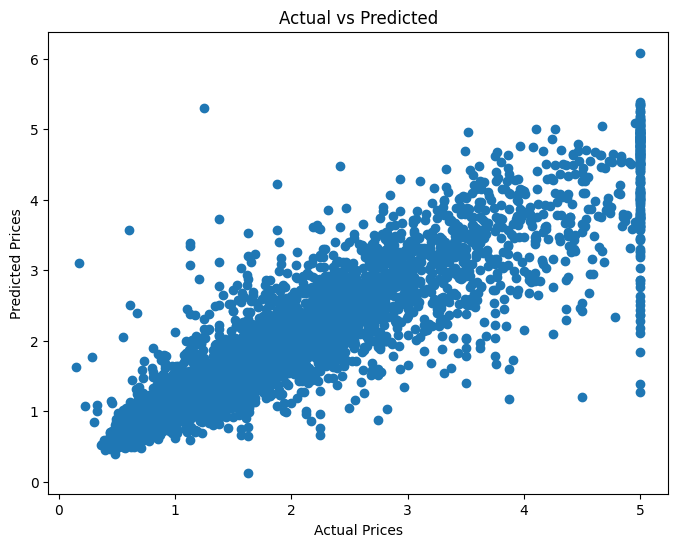

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()